# FEM vs 2D MBIR on Real Single-Image Data

This notebook applies the 3D physics-projected FEM-style inversion used in the FEM inversion notebooks to the real single-image magnetic phase data from `mbir_real_data.ipynb`.

The object structure is estimated from the MIP phase: we threshold the MIP to define the support, estimate a thickness map, convert that thickness map into a 3D occupancy field `rho`, and then run a single-image FEM reconstruction.

We compare the FEM result against the original 2D MBIR reconstruction from the notebook. There is no ground truth for the real dataset, so the comparison is based on phase fit, projected magnetization, and qualitative slice structure.

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.1'

import jax
import jax.numpy as jnp
jax.config.update('jax_enable_x64', True)

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom, gaussian_filter, rotate

from libertem_holo.base.mbir import (
    CombinedBackend,
    NeuralMagCritic,
    SmoothnessBackend,
    WeightedBackend,
    add_units_to_inputs,
    forward_model_2d,
    lcurve_sweep_vmap,
    make_quantity,
    reconstruct_2d,
    support_center_yx,
    vortex_magnetization,
)
from libertem_holo.base.mbir.physical import estimate_thickness_from_mip_phase

%matplotlib widget

/Users/landers/.conda/envs/holography_error/lib/python3.14/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda13_plugin version 0.9.1 is installed, but it is not compatible with the installed jaxlib version 0.9.0, so it will not be used.
  warnings.warn(


In [ ]:
def crop_to_mask(arrays, mask, pad=24):
    ys, xs = np.where(mask)
    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, mask.shape[0])
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, mask.shape[1])
    side = max(y1 - y0, x1 - x0)
    cy = 0.5 * (y0 + y1)
    cx = 0.5 * (x0 + x1)
    y0 = max(int(round(cy - side / 2)), 0)
    x0 = max(int(round(cx - side / 2)), 0)
    y1 = min(y0 + side, mask.shape[0])
    x1 = min(x0 + side, mask.shape[1])
    y0 = y1 - side
    x0 = x1 - side
    return [arr[y0:y1, x0:x1] for arr in arrays], (slice(y0, y1), slice(x0, x1))

def resize_2d(arr, target, order=1):
    scale = target / arr.shape[0]
    return np.asarray(zoom(arr, zoom=scale, order=order), dtype=np.float32)

def centered_thickness_rho(thickness_nm, pixel_size_nm, nz=32, single_z_voxel=False, mask_2d=None):
    if single_z_voxel:
        if mask_2d is None:
            mask_2d = np.asarray(thickness_nm, dtype=np.float32) > 0.0
        mask_2d = np.asarray(mask_2d, dtype=np.float32)
        return mask_2d[None, :, :]

    thickness_px = np.asarray(thickness_nm, dtype=np.float32) / float(pixel_size_nm)
    z0 = 0.5 * (nz - thickness_px)
    z1 = z0 + thickness_px
    z_lo = np.arange(nz, dtype=np.float32)[:, None, None]
    z_hi = z_lo + 1.0
    fill = np.clip(np.minimum(z_hi, z1[None, :, :]) - np.maximum(z_lo, z0[None, :, :]), 0.0, 1.0)
    return np.asarray(fill, dtype=np.float32)

def projected_from_volume(rho_zyx, m_zyxc):
    return np.sum(np.asarray(rho_zyx)[..., None] * np.asarray(m_zyxc), axis=0)[..., :2]

def normalize_field(m, rho, eps=1e-6):
    norms = np.linalg.norm(np.asarray(m, dtype=np.float32), axis=-1, keepdims=True)
    safe = np.where(norms > eps, norms, 1.0)
    unit = np.asarray(m, dtype=np.float32) / safe
    fallback = np.zeros_like(unit)
    fallback[..., 0] = 1.0
    unit = np.where(norms > eps, unit, fallback)
    return np.where(np.asarray(rho)[..., None] > 0.05, unit, 0.0).astype(np.float32)

def extrude_projected_init(rho, proj_2d):
    init = np.zeros(np.asarray(rho).shape + (3,), dtype=np.float32)
    init[..., 0] = np.asarray(proj_2d, dtype=np.float32)[None, ..., 0]
    init[..., 1] = np.asarray(proj_2d, dtype=np.float32)[None, ..., 1]
    return normalize_field(init, rho)

def flower_state_init(
    rho,
    proj_2d,
    *,
    center_yx=None,
    mz_sign=1.0,
    mz_strength=0.35,
    closure_strength=0.2,
    core_radius_px=None,
):
    rho_arr = np.asarray(rho, dtype=np.float32)
    init = extrude_projected_init(rho_arr, proj_2d)

    _, ny, nx = rho_arr.shape
    if center_yx is None:
        center_yx = support_center_yx(rho_arr, threshold=0.25)
    cy, cx = center_yx
    yy, xx = np.meshgrid(
        np.arange(ny, dtype=np.float32),
        np.arange(nx, dtype=np.float32),
        indexing='ij',
    )
    dy = yy - float(cy)
    dx = xx - float(cx)
    r = np.sqrt(dx ** 2 + dy ** 2)
    support_2d = np.max(rho_arr > 0.25, axis=0)
    if core_radius_px is None:
        support_area = max(int(np.sum(support_2d)), 1)
        core_radius_px = max(np.sqrt(support_area / np.pi) * 0.3, 2.0)
    r_safe = np.where(r > 1e-6, r, 1.0)
    radial_x = dx / r_safe
    radial_y = dy / r_safe
    center_envelope = np.exp(-(r / float(core_radius_px)) ** 2).astype(np.float32)
    edge_envelope = np.clip(r / max(float(core_radius_px), 1.0), 0.0, 1.0).astype(np.float32)

    closure = np.zeros_like(init)
    closure[..., 0] = closure_strength * radial_x[None, :, :] * edge_envelope[None, :, :]
    closure[..., 1] = closure_strength * radial_y[None, :, :] * edge_envelope[None, :, :]
    closure[..., 2] = mz_sign * mz_strength * center_envelope[None, :, :]

    return normalize_field(init + closure * rho_arr[..., None], rho_arr)

def vortex_state_init(
    rho,
    proj_2d,
    *,
    center_yx=None,
    chirality=1.0,
    mz_sign=1.0,
    vortex_strength=0.45,
    core_radius_px=None,
):
    rho_arr = np.asarray(rho, dtype=np.float32)
    init = extrude_projected_init(rho_arr, proj_2d)
    support_2d = np.max(rho_arr > 0.25, axis=0)
    if core_radius_px is None:
        support_area = max(int(np.sum(support_2d)), 1)
        core_radius_px = max(np.sqrt(support_area / np.pi) * 0.18, 1.5)
    shape_zyx = (int(rho_arr.shape[0]), int(rho_arr.shape[1]), int(rho_arr.shape[2]))
    vortex_prior = np.array(
        vortex_magnetization(
            shape_zyx,
            support_zyx=jnp.asarray(rho_arr),
            center_yx=center_yx,
            core_radius=float(core_radius_px),
            chirality=float(chirality),
            dtype=np.float32,
        ),
        dtype=np.float32,
        copy=True,
    )
    vortex_prior[..., 2] = mz_sign * np.abs(vortex_prior[..., 2])
    return normalize_field(init + vortex_strength * vortex_prior, rho_arr)

def tilt_volume_y(rho_zyx, m_zyxc, angle_deg, order=1):
    rho_arr = np.asarray(rho_zyx, dtype=np.float32)
    m_arr = np.asarray(m_zyxc, dtype=np.float32)
    axes = (0, 2)
    theta = np.deg2rad(angle_deg)
    rho_rot = rotate(
        rho_arr, angle_deg, axes=axes, reshape=False, order=order,
        mode='constant', cval=0.0, prefilter=False,
    )
    mx_rot = rotate(
        m_arr[..., 0], angle_deg, axes=axes, reshape=False, order=order,
        mode='constant', cval=0.0, prefilter=False,
    )
    my_rot = rotate(
        m_arr[..., 1], angle_deg, axes=axes, reshape=False, order=order,
        mode='constant', cval=0.0, prefilter=False,
    )
    mz_rot = rotate(
        m_arr[..., 2], angle_deg, axes=axes, reshape=False, order=order,
        mode='constant', cval=0.0, prefilter=False,
    )
    m_spatial = np.stack([mx_rot, my_rot, mz_rot], axis=-1)
    m_vector = np.empty_like(m_spatial)
    m_vector[..., 0] = np.cos(theta) * m_spatial[..., 0] + np.sin(theta) * m_spatial[..., 2]
    m_vector[..., 1] = m_spatial[..., 1]
    m_vector[..., 2] = -np.sin(theta) * m_spatial[..., 0] + np.cos(theta) * m_spatial[..., 2]
    return np.asarray(rho_rot, dtype=np.float32), normalize_field(m_vector, rho_rot)

def tilted_projection_from_volume(rho_zyx, m_zyxc, angle_deg):
    rho_tilt, m_tilt = tilt_volume_y(rho_zyx, m_zyxc, angle_deg=angle_deg)
    return projected_from_volume(rho_tilt, m_tilt)

def phase_rms(pred, true):
    pred = np.asarray(pred, dtype=np.float64)
    true = np.asarray(true, dtype=np.float64)
    return float(np.sqrt(np.mean((pred - true) ** 2)))

def magnetic_contour(phase, smooth=4, contour=16):
    return np.cos(gaussian_filter(np.asarray(phase), sigma=smooth) * contour)

def make_neuralmag_backend(rho, pixel_size_nm):
    import neuralmag as nm  # type: ignore[import-not-found]

    mesh = nm.Mesh(rho.shape, (pixel_size_nm * 1e-9,) * 3)
    state = nm.State(mesh)
    state.rho = nm.CellFunction(state, tensor=state.tensor(np.asarray(rho, dtype=np.float32)))
    state.material.Ms = nm.CellFunction(state).fill(4e5)
    state.material.A = nm.CellFunction(state).fill(1.3e-11)
    state.m = nm.VectorCellFunction(state, tensor=state.tensor(np.zeros(rho.shape + (3,), dtype=np.float32)))
    nm.ExchangeField().register(state, 'exchange')
    nm.DemagField(p=1).register(state, 'demag')
    return NeuralMagCritic.from_state(state, terms=('exchange', 'demag'))

def show_every_fourth_slices(m_recon, rho_ref, title):
    slice_indices = list(range(0, m_recon.shape[0], 4))
    components = [(0, 'Mx'), (1, 'My'), (2, 'Mz')]
    _, axes = plt.subplots(len(slice_indices), 3, figsize=(8, 2.0 * len(slice_indices)), squeeze=False)
    for row_idx, z_idx in enumerate(slice_indices):
        support = rho_ref[z_idx] > 0.25
        for comp_idx, comp_name in components:
            ax = axes[row_idx, comp_idx]
            ax.imshow(m_recon[z_idx, :, :, comp_idx], vmin=-1, vmax=1, cmap='RdBu_r')
            ax.contour(support, levels=[0.5], colors='k', linewidths=0.4)
            if row_idx == 0:
                ax.set_title(comp_name, fontsize=9)
            ax.set_ylabel(f'z={z_idx}', fontsize=8)
            ax.set_xticks([])
            ax.set_yticks([])
    plt.suptitle(title, y=1.0)
    plt.tight_layout()
    plt.show()

In [3]:
data_dir = os.path.dirname(os.getcwd())
mag_phase = np.load(os.path.join(data_dir, '/Users/landers/LiberTEM-holo/notebooks/MBIR/PosC_alpha0_phase_mag.npy'))
mip_phase = np.load(os.path.join(data_dir, '/Users/landers/LiberTEM-holo/notebooks/MBIR/PosC_alpha0_phase_mip.npy'))
pixel_size_nm_full = 0.58
mip_threshold = 3.0
crop_pad = 40
thickness_scale = 0.4
force_single_z_voxel = False
support_nz = 1 if force_single_z_voxel else 32
mask_full = (mip_phase > mip_threshold).astype(np.float32)

cropped, crop_slices = crop_to_mask([mag_phase, mip_phase, mask_full], mask_full > 0.5, pad=crop_pad)
mag_crop, mip_crop, mask_crop = cropped
target_size = 96
mag_small = resize_2d(mag_crop, target_size, order=1).astype(np.float32)
mip_small = resize_2d(mip_crop, target_size, order=1).astype(np.float32)
mask_small = (resize_2d(mask_crop, target_size, order=0) > 0.5).astype(np.float32)
pixel_size_nm_small = pixel_size_nm_full * (mag_crop.shape[0] / target_size)

quantities = add_units_to_inputs(mag_phase=mag_small, mip_phase=mip_small, pixel_size=pixel_size_nm_small, phase_unit='rad', pixel_size_unit='nm')
mag_phase_q = quantities['mag_phase']
mip_phase_q = quantities['mip_phase']
pixel_size_q = quantities['pixel_size']

mean_inner_potential = make_quantity(17.0, 'V')
thickness_map = estimate_thickness_from_mip_phase(mip_phase_q, mean_inner_potential=mean_inner_potential)
thickness_nm = np.asarray(thickness_map.value, dtype=np.float32) * mask_small
rho_guess = centered_thickness_rho(
    thickness_nm * thickness_scale,
    float(pixel_size_q.value),
    nz=support_nz,
    single_z_voxel=force_single_z_voxel,
    mask_2d=mask_small,
)
support_mode_label = 'single-z-voxel-1-layer' if force_single_z_voxel else 'thickness-inferred'
yx_center = support_center_yx(rho_guess, threshold=0.25)
occupied_z = np.where(np.any(rho_guess > 0.25, axis=(1, 2)))[0]
print('Support mode:', support_mode_label)
print('Crop pad:', crop_pad)
print('Cropped original shape:', mag_crop.shape)
print('Downsampled working shape:', mag_small.shape)
print('Thickness scale:', thickness_scale)
print('rho volume shape:', rho_guess.shape, 'center', yx_center)
print('Occupied z slices:', occupied_z.tolist())

Support mode: thickness-inferred
Crop pad: 40
Cropped original shape: (227, 227)
Downsampled working shape: (96, 96)
Thickness scale: 0.4
rho volume shape: (32, 96, 96) center (48, 48)
Occupied z slices: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


In [4]:
lambdas = np.logspace(-5, -1, 12)
lc = lcurve_sweep_vmap(phase=mag_phase_q, mask=mask_small, pixel_size=pixel_size_q, lambdas=lambdas, solver='newton_cg')
best_lam = lc.lambdas[lc.corner_index]
result_mbir = reconstruct_2d(phase=mag_phase_q, pixel_size=pixel_size_q, mask=mask_small, lam=best_lam, solver='newton_cg')
proj_mbir = np.asarray(result_mbir.magnetization.value)
pred_mbir = np.asarray(forward_model_2d(result_mbir.magnetization, pixel_size_q, ramp_coeffs=result_mbir.ramp_coeffs).value)
print('2D MBIR best lambda:', float(best_lam.value))

2D MBIR best lambda: 0.003511191734215131


In [97]:
import importlib
import libertem_holo.base.mbir.inversion.solver as inversion_solver_module

inversion_solver_module = importlib.reload(inversion_solver_module)
invert_magnetization = inversion_solver_module.invert_magnetization

backend_neuralmag = make_neuralmag_backend(rho_guess, float(pixel_size_q.value))
smoothness_relative_weight = 0.0
lambda_phys = 0.0
backend_fem = CombinedBackend(
    backend_neuralmag,
    WeightedBackend(SmoothnessBackend(), weight=smoothness_relative_weight),
)

screen_max_iter = 500
screen_lr = 1e-3
refine_max_iter = 4000
refine_adam_lr = 1e-3
refine_lbfgs_lr = 1.0

init_label = 'projected_mbir'
init_guess = extrude_projected_init(rho_guess, proj_mbir)

result_init = invert_magnetization(
    np.asarray(mag_small, dtype=np.float32),
    rho_guess,
    backend_fem,
    pixel_size=pixel_size_q,
    lambda_phys=lambda_phys,
    max_iter=screen_max_iter,
    lr=screen_lr,
    init=init_guess,
    axis='z',
    projection_threshold=0.0,
    fit_ramp=True,
    optimizer='adam',
)
m_init = np.asarray(result_init.m_recon)

early_stopping_patience = 200
early_stopping_min_delta = 1e-7

result_fem_adam = invert_magnetization(
    np.asarray(mag_small, dtype=np.float32),
    rho_guess,
    backend_fem,
    pixel_size=pixel_size_q,
    lambda_phys=lambda_phys,
    max_iter=refine_max_iter,
    lr=refine_adam_lr,
    init=m_init.astype(np.float32),
    axis='z',
    projection_threshold=0.0,
    fit_ramp=True,
    optimizer='adam',
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
)
m_fem_adam = np.asarray(result_fem_adam.m_recon)
proj_fem_adam = projected_from_volume(rho_guess, m_fem_adam)
pred_fem_adam = np.asarray(result_fem_adam.phi_pred)

result_fem_lbfgs = invert_magnetization(
    np.asarray(mag_small, dtype=np.float32),
    rho_guess,
    backend_fem,
    pixel_size=pixel_size_q,
    lambda_phys=lambda_phys,
    max_iter=refine_max_iter,
    lr=refine_lbfgs_lr,
    init=m_fem_adam.astype(np.float32),
    axis='z',
    projection_threshold=0.0,
    fit_ramp=True,
    optimizer='lbfgs',
    lbfgs_memory_size=10,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
)
m_fem_lbfgs = np.asarray(result_fem_lbfgs.m_recon)
proj_fem_lbfgs = projected_from_volume(rho_guess, m_fem_lbfgs)
pred_fem_lbfgs = np.asarray(result_fem_lbfgs.phi_pred)

result_fem = result_fem_lbfgs
m_fem = m_fem_lbfgs
proj_fem = proj_fem_lbfgs
pred_fem = pred_fem_lbfgs

support_mask = rho_guess > 0.25
print('Warm-start support voxels:', int(np.sum(support_mask)))
print('Warm-start projected mean |M|:', float(np.mean(np.linalg.norm(proj_mbir[mask_small > 0.5], axis=-1))))
print('Chosen init:', init_label)
print('Init phase RMS:', phase_rms(result_init.phi_pred, mag_small))
print('lambda_phys:', lambda_phys)
print('Smoothness relative weight:', smoothness_relative_weight)
print('Screen iterations:', screen_max_iter)
print('Early stopping patience:', early_stopping_patience)
print('Early stopping min delta:', early_stopping_min_delta)
print('Adam iterations:', int(np.asarray(result_fem_adam.loss_history).size))
print('Adam phase RMS:', phase_rms(pred_fem_adam, mag_small))
print('Adam mean |Mz| in support:', float(np.mean(np.abs(m_fem_adam[..., 2][support_mask]))))
print('L-BFGS iterations:', int(np.asarray(result_fem_lbfgs.loss_history).size))
print('L-BFGS phase RMS:', phase_rms(pred_fem_lbfgs, mag_small))
print('L-BFGS mean |Mz| in support:', float(np.mean(np.abs(m_fem_lbfgs[..., 2][support_mask]))))
print('L-BFGS fitted ramp offset (rad):', float(result_fem_lbfgs.ramp_coeffs.offset.value))
print('L-BFGS fitted ramp slopes (rad/nm):', float(result_fem_lbfgs.ramp_coeffs.slope_y.value), float(result_fem_lbfgs.ramp_coeffs.slope_x.value))

2026-04-21 15:05:48 NeuralMag:INFO [Mesh] 3D, 32 x 96 x 96 (size = 1.37146e-09 x 1.37146e-09 x 1.37146e-09)
2026-04-21 15:05:48 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-21 15:05:48 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-21 15:05:48 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-21 15:05:48 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-21 15:05:48 NeuralMag:INFO [DemagField]: Set up demag tensor


Warm-start support voxels: 50616
Warm-start projected mean |M|: 14.705140833989926
Chosen init: projected_mbir
Init phase RMS: 0.058793145311189725
lambda_phys: 0.0
Smoothness relative weight: 0.0
Screen iterations: 500
Early stopping patience: 200
Early stopping min delta: 1e-07
Adam iterations: 4000
Adam phase RMS: 0.03882511641647669
Adam mean |Mz| in support: 0.0
L-BFGS iterations: 366
L-BFGS phase RMS: 0.0381130529380603
L-BFGS mean |Mz| in support: 0.0
L-BFGS fitted ramp offset (rad): -0.01525842866021284
L-BFGS fitted ramp slopes (rad/nm): 0.0005782013214523108 -0.000839442270889631


In [98]:
exp_mc = magnetic_contour(mag_small, smooth=4, contour=16)
mbir_mc = magnetic_contour(pred_mbir, smooth=4, contour=16)
fem_mc = magnetic_contour(pred_fem, smooth=4, contour=16)

def corr(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    return float(np.corrcoef(a, b)[0, 1])

loss_history_fem = np.asarray(result_fem.loss_history, dtype=np.float64)
finite_loss_count_fem = int(np.isfinite(loss_history_fem).sum())

print(f"{'Method':<20} {'phase_rms':>12} {'contour_corr':>14} {'finite_loss':>14}")


Method                  phase_rms   contour_corr    finite_loss


In [99]:
print('-' * 66)
print(f"{'2D MBIR':<20} {phase_rms(pred_mbir, mag_small):>12.6f} {corr(exp_mc, mbir_mc):>14.6f} {'-':>14}")
print(
    f"{'3D FEM L-BFGS':<20} "
    f"{phase_rms(pred_fem, mag_small):>12.6f} "
    f"{corr(exp_mc, fem_mc):>14.6f} "
    f"{finite_loss_count_fem:>6d}/{loss_history_fem.size:<7d}"
)

print('L-BFGS ramp offset (rad):', float(result_fem.ramp_coeffs.offset.value))
print(
    'L-BFGS ramp slopes (rad/nm):',
    float(result_fem.ramp_coeffs.slope_y.value),
    float(result_fem.ramp_coeffs.slope_x.value),
)

------------------------------------------------------------------
2D MBIR                  0.041118       0.990132              -
3D FEM L-BFGS            0.038113       0.988182    366/366    
L-BFGS ramp offset (rad): -0.01525842866021284
L-BFGS ramp slopes (rad/nm): 0.0005782013214523108 -0.000839442270889631


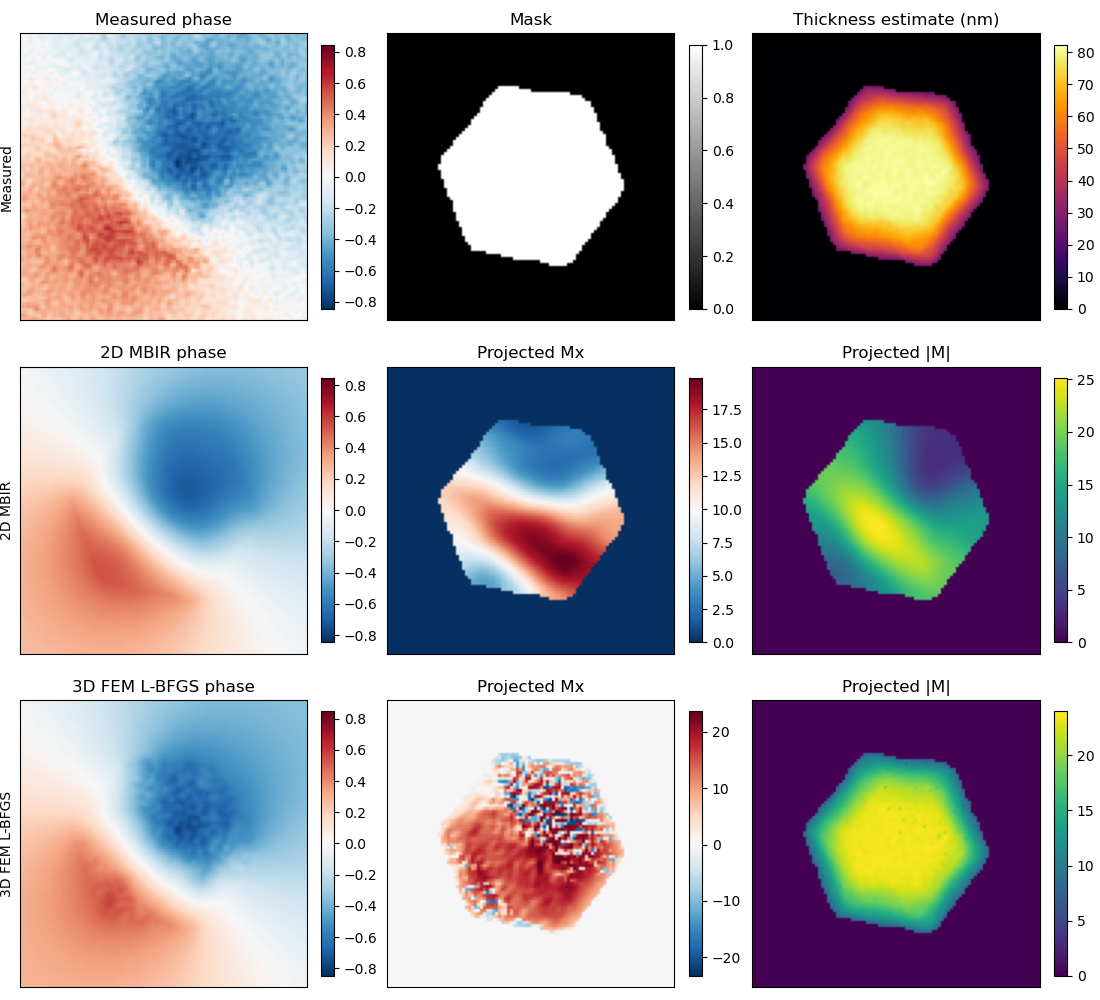

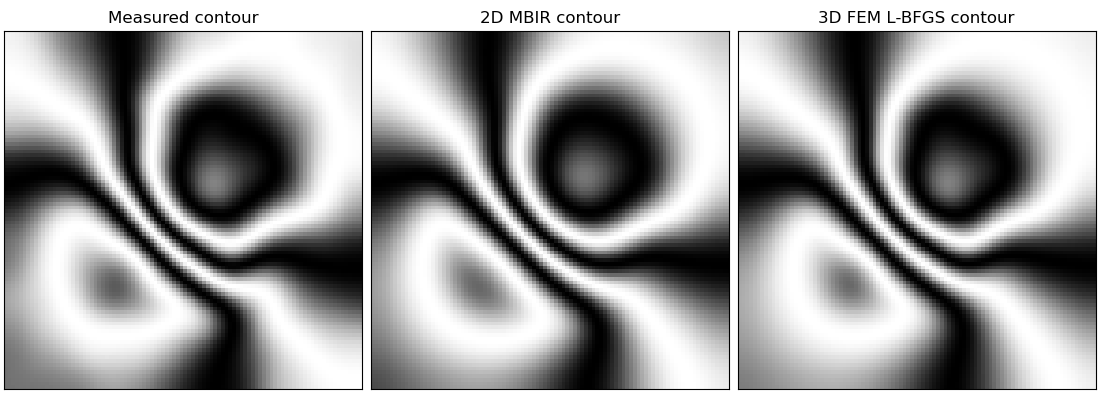

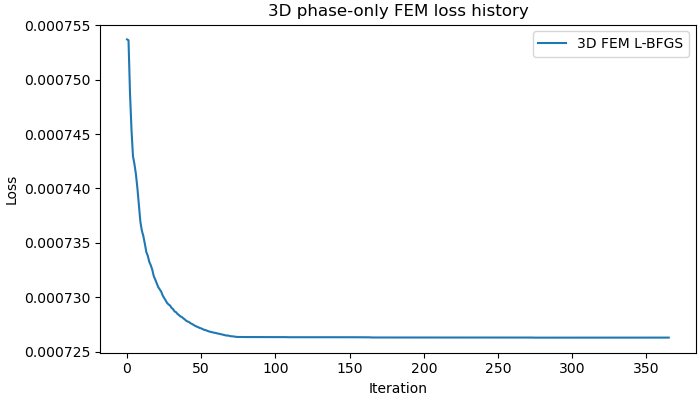

In [100]:
fig, axs = plt.subplots(3, 3, figsize=(11, 10), constrained_layout=True)

rows = [
    ('Measured', mag_small, None),
    ('2D MBIR', pred_mbir, proj_mbir),
    ('3D FEM L-BFGS', pred_fem, proj_fem),
]

for row_idx, (label, phase_img, proj_field) in enumerate(rows):
    vmax_phase = max(np.max(np.abs(mag_small)), np.max(np.abs(phase_img)), 1e-12)
    im0 = axs[row_idx, 0].imshow(phase_img, cmap='RdBu_r', vmin=-vmax_phase, vmax=vmax_phase)
    axs[row_idx, 0].set_title(f'{label} phase')
    axs[row_idx, 0].set_ylabel(label)
    plt.colorbar(im0, ax=axs[row_idx, 0], fraction=0.046)
    if proj_field is None:
        im1 = axs[row_idx, 1].imshow(mask_small, cmap='gray')
        axs[row_idx, 1].set_title('Mask')
        im2 = axs[row_idx, 2].imshow(thickness_nm, cmap='inferno')
        axs[row_idx, 2].set_title('Thickness estimate (nm)')
    else:
        mag_norm = np.linalg.norm(proj_field, axis=-1)
        im1 = axs[row_idx, 1].imshow(proj_field[..., 0], cmap='RdBu_r')
        axs[row_idx, 1].set_title('Projected Mx')
        im2 = axs[row_idx, 2].imshow(mag_norm, cmap='viridis')
        axs[row_idx, 2].set_title('Projected |M|')
    plt.colorbar(im1, ax=axs[row_idx, 1], fraction=0.046)
    plt.colorbar(im2, ax=axs[row_idx, 2], fraction=0.046)
    for col in range(3):
        axs[row_idx, col].set_xticks([])
        axs[row_idx, col].set_yticks([])
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(11, 4.2), constrained_layout=True)
axs[0].imshow(exp_mc, cmap='gray')
axs[0].set_title('Measured contour')
axs[1].imshow(mbir_mc, cmap='gray')
axs[1].set_title('2D MBIR contour')
axs[2].imshow(fem_mc, cmap='gray')
axs[2].set_title('3D FEM L-BFGS contour')
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(result_fem.loss_history, label='3D FEM L-BFGS')
ax.set_title('3D phase-only FEM loss history')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.legend()
plt.show()

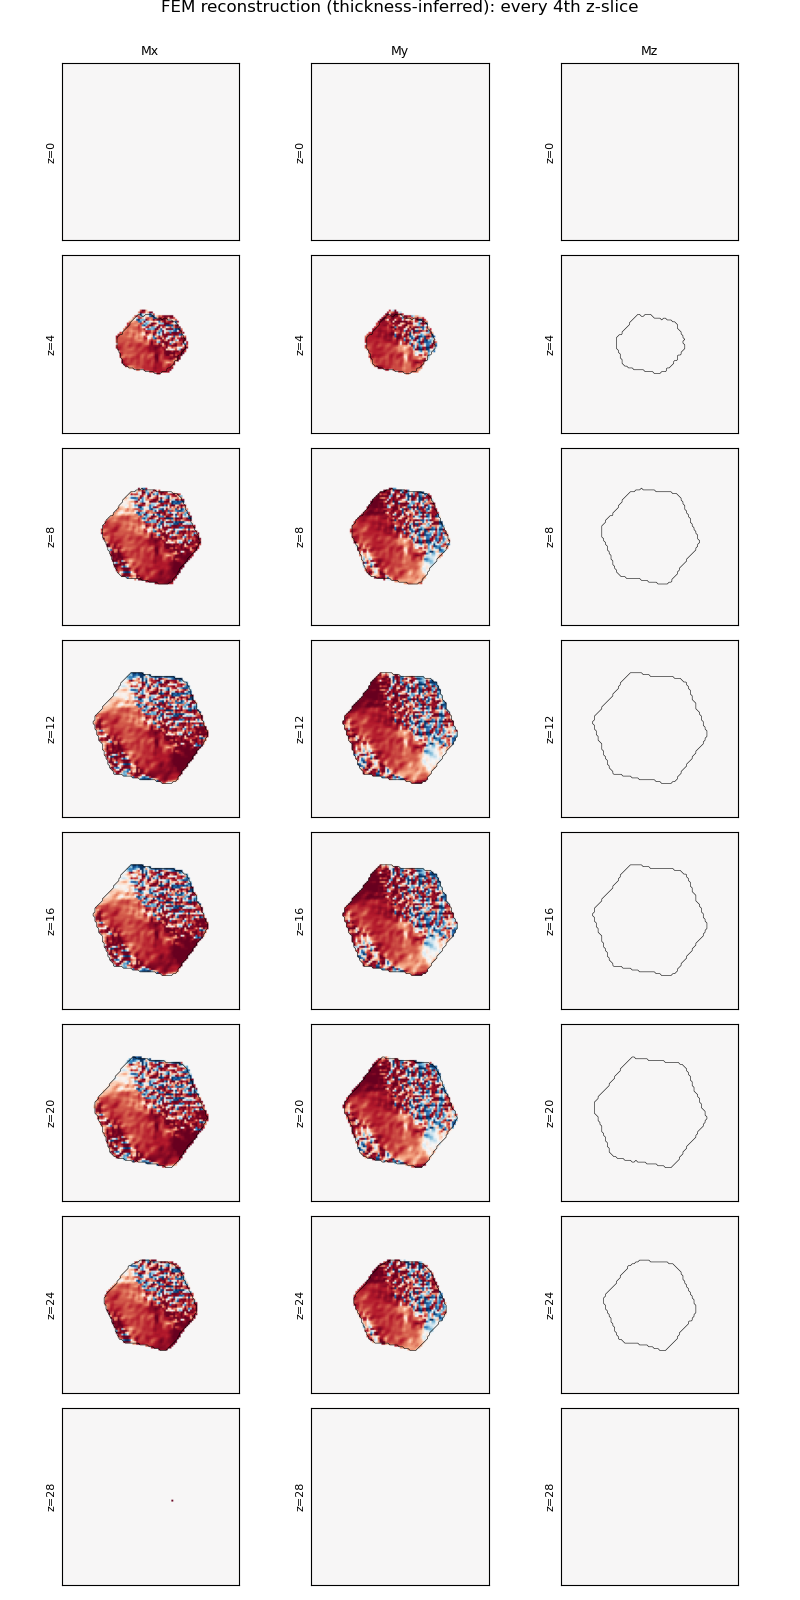

In [101]:
show_every_fourth_slices(m_fem_lbfgs, rho_guess, f'FEM reconstruction ({support_mode_label}): every 4th z-slice')

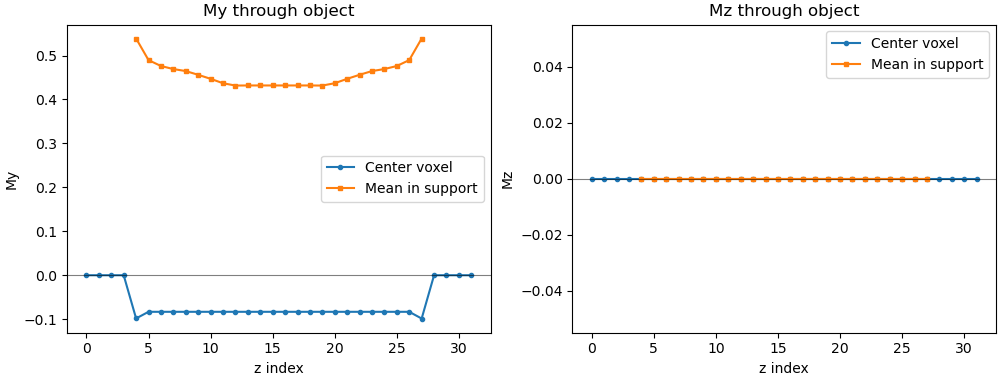

Center voxel (y, x): (48, 48)
My center range: -0.09860415756702423 0.0
Mz center range: 0.0 0.0


In [102]:
z_axis = np.arange(m_fem.shape[0])
y_center, x_center = yx_center
support_per_z = rho_guess > 0.25

my_center = m_fem[:, y_center, x_center, 1]
mz_center = m_fem[:, y_center, x_center, 2]
my_mean = np.array([
    np.mean(m_fem[z_idx, ..., 1][support_per_z[z_idx]]) if np.any(support_per_z[z_idx]) else np.nan
    for z_idx in range(m_fem.shape[0])
])
mz_mean = np.array([
    np.mean(m_fem[z_idx, ..., 2][support_per_z[z_idx]]) if np.any(support_per_z[z_idx]) else np.nan
    for z_idx in range(m_fem.shape[0])
])

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
axs[0].plot(z_axis, my_center, marker='o', ms=3, label='Center voxel')
axs[0].plot(z_axis, my_mean, marker='s', ms=3, label='Mean in support')
axs[0].axhline(0.0, color='k', lw=0.8, alpha=0.5)
axs[0].set_title('My through object')
axs[0].set_xlabel('z index')
axs[0].set_ylabel('My')
axs[0].legend()

axs[1].plot(z_axis, mz_center, marker='o', ms=3, label='Center voxel')
axs[1].plot(z_axis, mz_mean, marker='s', ms=3, label='Mean in support')
axs[1].axhline(0.0, color='k', lw=0.8, alpha=0.5)
axs[1].set_title('Mz through object')
axs[1].set_xlabel('z index')
axs[1].set_ylabel('Mz')
axs[1].legend()

plt.show()

print('Center voxel (y, x):', (y_center, x_center))
print('My center range:', float(np.min(my_center)), float(np.max(my_center)))
print('Mz center range:', float(np.min(mz_center)), float(np.max(mz_center)))